
# Case Study — Multi-Asset Ledger-Aware Backtest (Inspired by nouveau 2)

This notebook builds a refined **3-symbol case study** on **NVDA, AMZN, AAPL** using the current backtest stack:

- Multi-asset event-driven engine
- Realistic execution frictions (fees/slippage/spread)
- Portfolio constraints (weights, notional/exposure controls)
- **Accounting ledger outputs** (per-symbol cost basis, realized/unrealized PnL, journal, portfolio exposure)

Compared with `nouveau 2.ipynb`, this version is structured as a full research case-study with richer diagnostics and accounting-aware visualization.

This refresh also demonstrates the new **per-symbol stop-loss + cooldown** controls in `EngineConfig`.


In [1]:

# Optional: use autoreload if working interactively
%load_ext autoreload
%autoreload 2


In [2]:

from __future__ import annotations

from collections import defaultdict, deque
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from analytics.tearsheet import make_tearsheet_with_details
from data.loaders.yfinance_loader import load_yfinance
from engine.core.backtest_engine import BacktestEngine, EngineConfig
from engine.core.event import MarketEvent


## 1) Universe + configuration (with stop-loss + cooldown)


In [65]:
INITIAL_CASH = 100_000
MAX_ABS_EXPOSURE = 3.0  # max leverage (e.g. 2.0 means you can be long $200k or short $200k with $100k cash)
SYMBOLS = ["NVDA", "AMZN", "AAPL", "MSFT", "GOOGL"]
PERIOD = "2y"
INTERVAL = "60m"
PREPOST = True,   # include pre/post market
AUTO_ADJUST = True, #adjust prices for splits & dividends (NVDIA had a 4-for-1 split in July 2023, so this is important to set to True)
PROGRESS = False
MAX_TRADES_PER_DAY = 10  # max number of trades per day (BUY or SELL or BOTH based on TRADE_CAP_SIDE) - set to None for no cap
TRADE_CAP_SIDE = "buy"  # "buy", "sell", "both" [default: "both"] - which side(s) to apply the max trades per day cap to

cfg = EngineConfig(
    initial_cash=INITIAL_CASH,
    fee_bps=0.5,
    slippage_bps=0.5,
    spread_bps=0.25,
    latency_bars=1,
    max_abs_weight=0.50,
    max_abs_exposure=MAX_ABS_EXPOSURE,
    max_notional=INITIAL_CASH*MAX_ABS_EXPOSURE/len(SYMBOLS),  # max position size in dollars
    allow_short=False,
    borrow_rate_bps=30.0,
    financing_bars_per_year=252,
    stop_loss_mode="pct",
    stop_loss_value=0.10,  # 10% stop loss
    stop_cooldown_bars=5,
    max_trades_per_day=MAX_TRADES_PER_DAY,
    trade_cap_side=TRADE_CAP_SIDE,
)

print("Risk controls:")
print({
    "max_abs_weight": cfg.max_abs_weight,
    "max_abs_exposure": cfg.max_abs_exposure,
    "max_notional": cfg.max_notional,
    "stop_loss_mode": cfg.stop_loss_mode,
    "stop_loss_value": cfg.stop_loss_value,
    "stop_cooldown_bars": cfg.stop_cooldown_bars,
})


Risk controls:
{'max_abs_weight': 0.5, 'max_abs_exposure': 3.0, 'max_notional': 60000.0, 'stop_loss_mode': 'pct', 'stop_loss_value': 0.1, 'stop_cooldown_bars': 5}


## 2) Load and align the 3-symbol universe

In [55]:

def load_universe(symbols: list[str], period: str, interval: str, auto_adjust: bool, prepost: bool, progress: bool) -> list[MarketEvent]:
    bars_by_symbol: dict[str, list[MarketEvent]] = {}
    for symbol in symbols:
        bars_by_symbol[symbol] = load_yfinance(symbol=symbol, period=period, interval=interval, auto_adjust=auto_adjust, prepost=prepost, progress=progress)

    common_timestamps = None
    for symbol, bars in bars_by_symbol.items():
        ts = {b.timestamp for b in bars}
        common_timestamps = ts if common_timestamps is None else (common_timestamps & ts)

    if not common_timestamps:
        return []

    common_timestamps = set(common_timestamps)
    merged: list[MarketEvent] = []
    for symbol in symbols:
        filtered = [b for b in bars_by_symbol[symbol] if b.timestamp in common_timestamps]
        merged.extend(filtered)

    merged.sort(key=lambda x: (x.timestamp, x.symbol))
    return merged

bars = load_universe(SYMBOLS, PERIOD, INTERVAL, AUTO_ADJUST, PREPOST, PROGRESS)
print(f"Loaded bars: {len(bars)}")
print(f"First bar: {bars[0] if bars else 'None'}")


Loaded bars: 41385
First bar: MarketEvent(timestamp='2024-03-11 08:00', symbol='AAPL', close=171.66, open=172.41, high=172.41, low=170.89, volume=0.0)


## 3) Strategy: adaptive trend + pullback blend (creative variant)

In [ ]:

@dataclass
class AdaptiveTrendPullback:
    lookback_mom: int = 30
    lookback_vol: int = 20
    pullback_window: int = 10
    top_k: int = 2

    def __post_init__(self) -> None:
        self.prices: dict[str, deque[float]] = defaultdict(lambda: deque(maxlen=max(self.lookback_mom + 1, self.lookback_vol + 2, self.pullback_window + 2)))

    def _ret(self, series: list[float], n: int) -> float:
        if len(series) <= n or series[-n-1] == 0:
            return 0.0
        return (series[-1] / series[-n-1]) - 1.0

    def _vol(self, series: list[float], n: int) -> float:
        if len(series) < n + 1:
            return 0.0
        rets = []
        for i in range(-n, 0):
            prev = series[i-1]
            cur = series[i]
            rets.append((cur / prev) - 1.0 if prev else 0.0)
        return float(np.std(rets))

    def on_bars(self, bars_by_symbol: dict[str, MarketEvent]) -> dict[str, float]:
        scores: list[tuple[str, float, float]] = []

        for symbol, bar in bars_by_symbol.items():
            self.prices[symbol].append(bar.close)
            s = list(self.prices[symbol])
            if len(s) < max(self.lookback_mom + 1, self.lookback_vol + 1, self.pullback_window + 1):
                continue

            mom = self._ret(s, self.lookback_mom)
            vol = self._vol(s, self.lookback_vol)
            pullback = self._ret(s, self.pullback_window)

            # composite score:
            # - trend positive (mom)
            # - penalize high vol
            # - mild contrarian boost when recent pullback is negative
            score = mom - 0.5 * vol + 0.3 * (-pullback)
            scores.append((symbol, score, vol))

        if len(scores) < self.top_k:
            return {symbol: 0.0 for symbol in bars_by_symbol}

        scores.sort(key=lambda x: x[1], reverse=True)
        longs = scores[: self.top_k]
        shorts = scores[-self.top_k :]

        # inverse-vol risk scaling
        def inv_vol(v: float) -> float:
            return 1.0 / max(v, 1e-6)

        long_scale = sum(inv_vol(v) for _, _, v in longs)
        short_scale = sum(inv_vol(v) for _, _, v in shorts)

        targets = {symbol: 0.0 for symbol in bars_by_symbol}
        for symbol, _, vol in longs:
            targets[symbol] += 0.5 * (inv_vol(vol) / long_scale)
        for symbol, _, vol in shorts:
            targets[symbol] -= 0.5 * (inv_vol(vol) / short_scale)

        return targets

strategy = AdaptiveTrendPullback()


In [57]:
from strategies.moving_average import MovingAverageStrategy
from strategies.zlema import ZLEMAStrategy
from strategies.hull_moving_average import HullMovingAverageStrategy
from strategies.kama import KAMAStrategy
from strategies.momentum import MomentumStrategy
from strategies.mean_reversion import MeanReversionStrategy


#strategy = HullMovingAverageStrategy()
#stategy = ZLEMAStrategy()
#strategy = MovingAverageStrategy(fast_window=50,slow_window=200)
#strategy = KAMAStrategy()
#strategy = MomentumStrategy()
strategy = MeanReversionStrategy()

## 4) Run backtest and compute headline metrics

In [66]:

engine = BacktestEngine(cfg)
result = engine.run_detailed(bars, strategy)

# representative price series aligned to timestamps (use first symbol per timestamp)
bars_df = pd.DataFrame([{"timestamp": b.timestamp, "symbol": b.symbol, "close": b.close} for b in bars])
price_ref = bars_df.sort_values(["timestamp", "symbol"]).groupby("timestamp", as_index=False).first()
prices = price_ref["close"].tolist()[: len(result.positions)]

metrics = make_tearsheet_with_details(
    equity_curve=result.equity_curve,
    annualization=252,
    fills=result.fills,
    positions=result.positions,
    prices=prices,
    rolling_window=20,
)

pd.Series(metrics).sort_index()


AvgAbsExposure                 0.303042
AvgDrawdownDurationBars      408.169154
CAGR                           0.001156
Calmar                         0.005655
MaxDrawdown                   -0.204403
MaxDrawdownDurationBars    17255.000000
NumTrades                   1686.000000
PeakAbsExposure                2.086613
RollingSharpeLast              0.000000
RollingSharpeMean             -0.270704
Sharpe                         0.116867
Turnover                    1347.541707
WinRate                        0.551008
dtype: float64

## 5) Build ledger dataframes

In [67]:

fills_df = pd.DataFrame([
    {
        "timestamp": f.timestamp,
        "symbol": f.symbol,
        "side": f.side,
        "quantity": f.quantity,
        "fill_price": f.fill_price,
        "fee": f.fee,
    }
    for f in result.fills
])

sym_df = pd.DataFrame(result.positions_by_symbol)
port_df = pd.DataFrame(result.portfolio_history)
journal_df = pd.DataFrame(result.journal)
trade_attr_df = pd.DataFrame(result.trade_attribution)

for df in [sym_df, port_df, journal_df, trade_attr_df, fills_df]:
    if not df.empty and "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"])

print("fills:", len(fills_df))
print("symbol snapshots:", len(sym_df))
print("portfolio snapshots:", len(port_df))
print("journal entries:", len(journal_df))
print("trade attribution rows:", len(trade_attr_df))


fills: 5375
symbol snapshots: 41237
portfolio snapshots: 8277
journal entries: 7760
trade attribution rows: 2385


## 6) Plot A — Equity + drawdown (kept and refined)

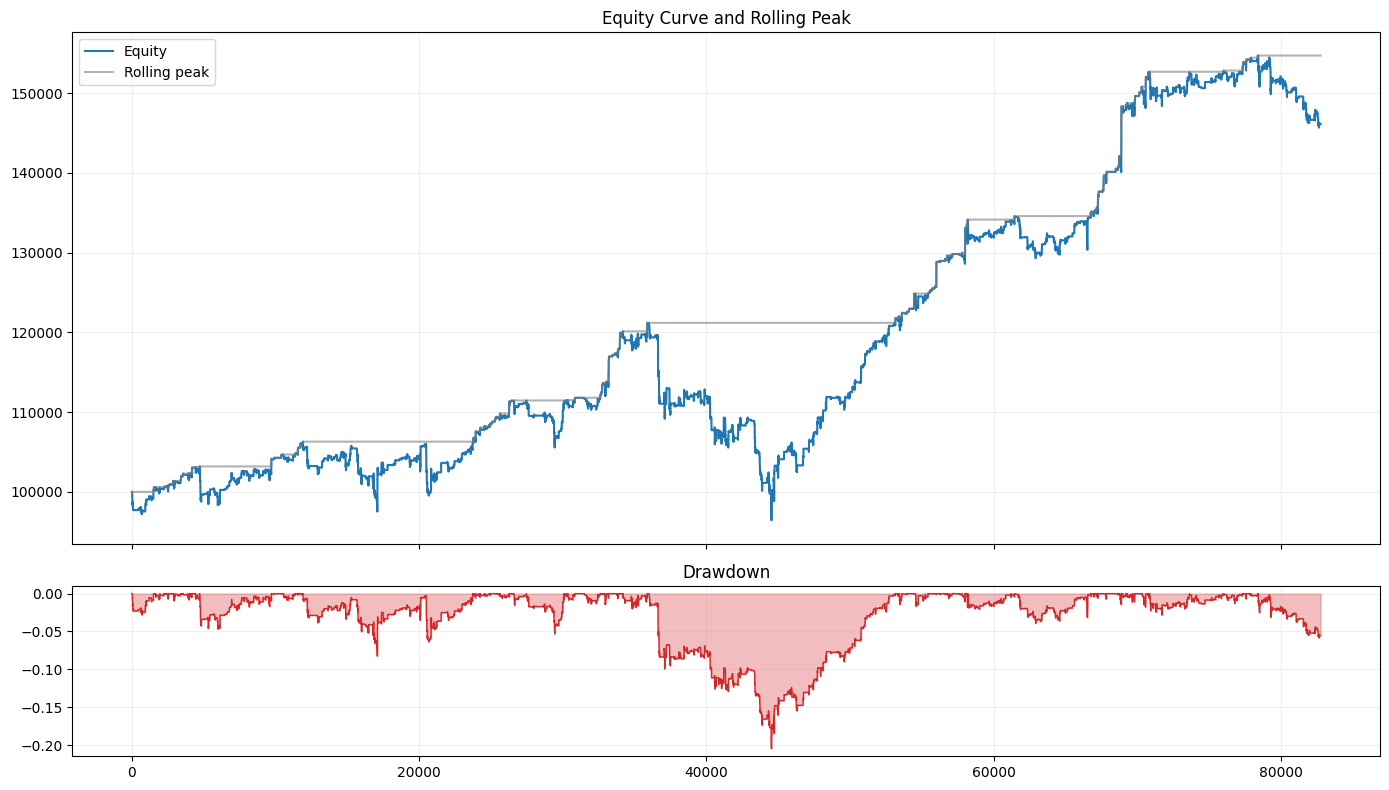

In [68]:

eq = pd.Series(result.equity_curve, name="equity")
roll_max = eq.cummax()
drawdown = (eq / roll_max) - 1.0

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(eq.values, label="Equity", color="tab:blue")
axes[0].plot(roll_max.values, label="Rolling peak", color="tab:gray", alpha=0.6)
axes[0].set_title("Equity Curve and Rolling Peak")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].fill_between(range(len(drawdown)), drawdown.values, 0, color="tab:red", alpha=0.3)
axes[1].plot(drawdown.values, color="tab:red", linewidth=1)
axes[1].set_title("Drawdown")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [44]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -----------------------------
# 1) Build dataframes
# -----------------------------
bars_df = pd.DataFrame([
    {
        "timestamp": pd.to_datetime(b.timestamp),
        "symbol": b.symbol,
        "open": b.open,
        "high": b.high,
        "low": b.low,
        "close": b.close,
        "volume": b.volume,
    }
    for b in bars
]).sort_values(["symbol", "timestamp"])

fills_df = pd.DataFrame([
    {
        "timestamp": pd.to_datetime(f.timestamp),
        "symbol": f.symbol,
        "side": str(f.side).upper(),
        "qty": f.quantity,
        "fill_price": f.fill_price,
        "fee": f.fee,
    }
    for f in result.fills
]).sort_values(["symbol", "timestamp"])

symbols = sorted(bars_df["symbol"].unique())
n = len(symbols)

# -----------------------------
# 2) Create subplots
# -----------------------------
fig = make_subplots(
    rows=n,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    row_heights=[0.34, 0.33, 0.33] if n == 3 else None,
    subplot_titles=[f"{sym} Candles + Trades" for sym in symbols]
)

# -----------------------------
# 3) Add one subplot per symbol
# -----------------------------
for i, sym in enumerate(symbols, start=1):
    sym_price = bars_df[bars_df["symbol"] == sym]
    sym_fills = fills_df[fills_df["symbol"] == sym]

    fig.add_trace(
        go.Candlestick(
            x=sym_price["timestamp"],
            open=sym_price["open"],
            high=sym_price["high"],
            low=sym_price["low"],
            close=sym_price["close"],
            name=sym,
            showlegend=False
        ),
        row=i,
        col=1
    )

    if not sym_fills.empty:
        aligned = pd.merge_asof(
            sym_fills.sort_values("timestamp"),
            sym_price[["timestamp", "close"]].sort_values("timestamp"),
            on="timestamp",
            direction="nearest"
        )

        buys = aligned[aligned["side"] == "BUY"]
        sells = aligned[aligned["side"] == "SELL"]

        if not buys.empty:
            fig.add_trace(
                go.Scatter(
                    x=buys["timestamp"],
                    y=buys["close"],
                    mode="markers",
                    name=f"{sym} BUY",
                    marker=dict(
                        symbol="triangle-up",
                        color="orange",
                        size=12,
                        line=dict(color="black", width=1)
                    ),
                    customdata=buys[["qty", "fill_price", "fee"]].to_numpy(),
                    hovertemplate=(
                        f"{sym} BUY<br>"
                        "Time: %{x}<br>"
                        "Price: %{y:.2f}<br>"
                        "Qty: %{customdata[0]:.4f}<br>"
                        "Fill: %{customdata[1]:.2f}<br>"
                        "Fee: %{customdata[2]:.4f}"
                        "<extra></extra>"
                    ),
                ),
                row=i,
                col=1
            )

        if not sells.empty:
            fig.add_trace(
                go.Scatter(
                    x=sells["timestamp"],
                    y=sells["close"],
                    mode="markers",
                    name=f"{sym} SELL",
                    marker=dict(
                        symbol="triangle-down",
                        color="blue",
                        size=12,
                        line=dict(color="black", width=1)
                    ),
                    customdata=sells[["qty", "fill_price", "fee"]].to_numpy(),
                    hovertemplate=(
                        f"{sym} SELL<br>"
                        "Time: %{x}<br>"
                        "Price: %{y:.2f}<br>"
                        "Qty: %{customdata[0]:.4f}<br>"
                        "Fill: %{customdata[1]:.2f}<br>"
                        "Fee: %{customdata[2]:.4f}"
                        "<extra></extra>"
                    ),
                ),
                row=i,
                col=1
            )

    fig.update_yaxes(
        title_text=sym,
        fixedrange=False,
        automargin=True,
        row=i,
        col=1
    )

# -----------------------------
# 4) Hide non-trading gaps
# -----------------------------
fig.update_xaxes(
    rangebreaks=[
        dict(bounds=["sat", "mon"]),
        dict(bounds=[16, 9.5], pattern="hour")
    ]
)

# -----------------------------
# 5) Disable sliders everywhere
# -----------------------------
fig.update_xaxes(rangeslider_visible=False)

# Enable only on bottom subplot
fig.update_xaxes(
    rangeslider_visible=True,
    rangeslider_thickness=0.06,
    rangeselector=dict(
        buttons=[
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=3, label="3m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all", label="All"),
        ]
    ),
    row=n,
    col=1
)

# -----------------------------
# 6) Layout improvements
# -----------------------------
fig.update_layout(
    title="Per-Symbol Candlestick Charts with Buy/Sell Markers",
    height=430 * n,
    hovermode="closest",
    dragmode="zoom",
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    ),
    margin=dict(l=80, r=200, t=80, b=80),
)

fig.show()

## 7) Plot B — Symbol-level market value exposure from ledger

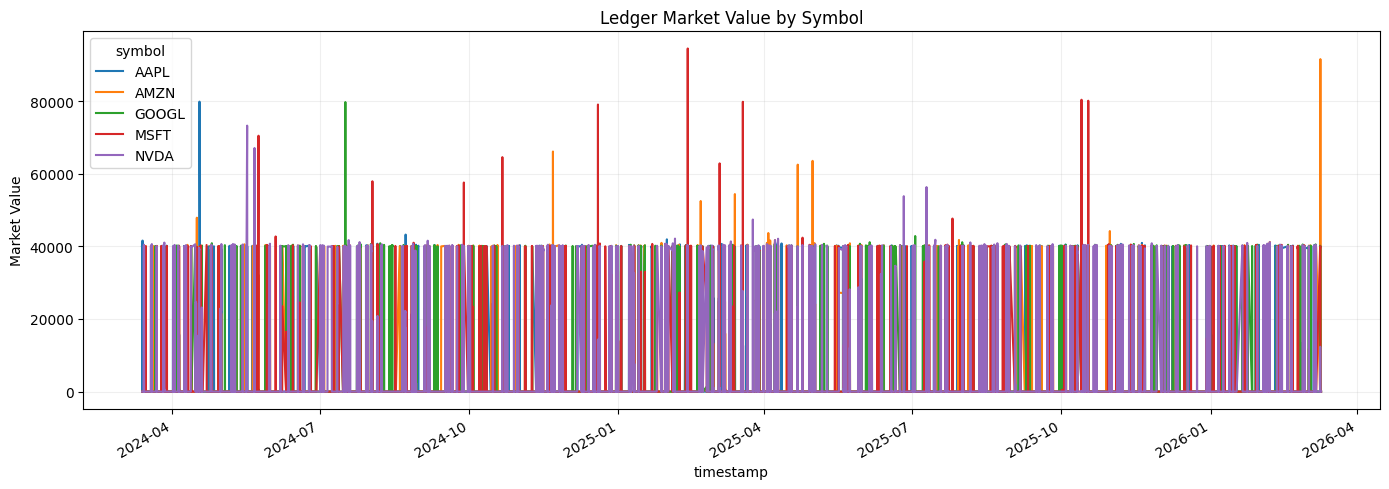

In [61]:

if not sym_df.empty:
    expo = sym_df.pivot_table(index="timestamp", columns="symbol", values="market_value", aggfunc="last").fillna(0.0)

    ax = expo.plot(figsize=(14, 5), linewidth=1.5)
    ax.set_title("Ledger Market Value by Symbol")
    ax.set_ylabel("Market Value")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("No symbol snapshot data available")


## 8) Plot C — Realized vs unrealized PnL by symbol (ledger refinement)

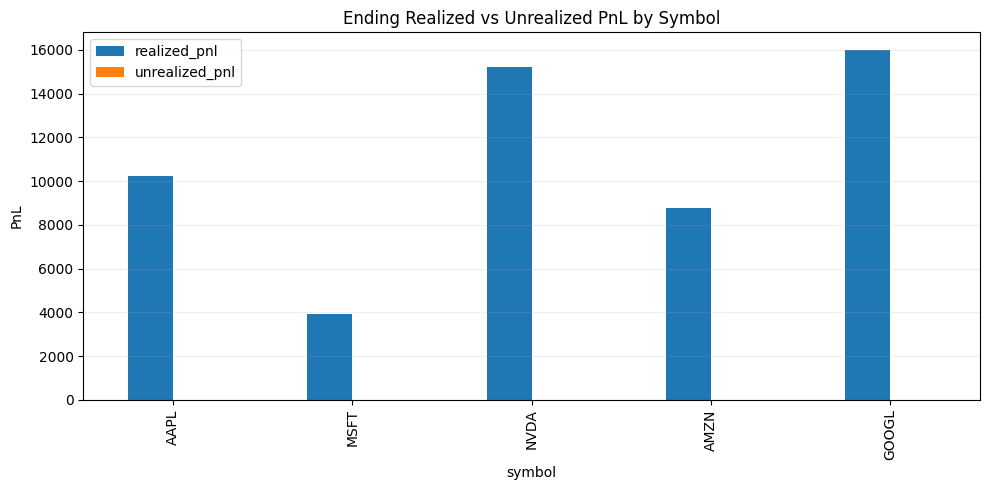

,symbol,quantity,avg_cost,last_price,realized_pnl,unrealized_pnl,total_pnl
41236,GOOGL,0.0,0.0,304.8415,16006.765472,0.0,14472.066115
41232,NVDA,0.0,0.0,181.6800,15231.405854,0.0,13564.830989
41234,AAPL,0.0,0.0,259.5599,10216.071413,0.0,8676.504413
41233,AMZN,0.0,0.0,212.8000,8790.480715,0.0,7105.956850
41235,MSFT,0.0,0.0,408.6700,3921.609635,0.0,2324.048045


In [69]:

if not sym_df.empty:
    last_snap = sym_df.sort_values("timestamp").groupby("symbol", as_index=False).tail(1)
    pnl_plot = last_snap[["symbol", "realized_pnl", "unrealized_pnl"]].set_index("symbol")

    ax = pnl_plot.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Ending Realized vs Unrealized PnL by Symbol")
    ax.set_ylabel("PnL")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

    display(last_snap[["symbol", "quantity", "avg_cost", "last_price", "realized_pnl", "unrealized_pnl", "total_pnl"]].sort_values("total_pnl", ascending=False))
else:
    print("No symbol snapshot data available")


## 9) Journal + stop-loss diagnostics

Use fills and ledger to inspect de-risking behavior. In long-only runs, clusters of SELL fills after adverse moves can indicate stop-loss liquidations, while delayed re-buys reflect cooldown.


In [70]:
if not journal_df.empty:
    summary = journal_df.groupby("entry_type", as_index=False)["amount"].sum().sort_values("amount")
    display(summary)

    if "BORROW_COST" in set(journal_df["entry_type"]):
        borrow = journal_df[journal_df["entry_type"] == "BORROW_COST"].copy()
        borrow = borrow.sort_values("timestamp")
        borrow["cum_borrow"] = borrow["amount"].cumsum()

        ax = borrow.plot(x="timestamp", y="cum_borrow", figsize=(12, 4), legend=False)
        ax.set_title("Cumulative Borrow Cost")
        ax.set_ylabel("Amount")
        ax.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()
else:
    print("No journal entries available")

if not fills_df.empty:
    sell_fills = fills_df[fills_df["side"] == "SELL"].sort_values("timestamp")
    print(f"SELL fills: {len(sell_fills)} / total fills: {len(fills_df)}")
    if not sell_fills.empty:
        display(sell_fills.tail(15))
else:
    print("No fills available")


,entry_type,amount
0,FEE,-8022.926679
1,REALIZED_PNL,54166.333090


SELL fills: 2385 / total fills: 5375


,timestamp,symbol,side,quantity,fill_price,fee
5340,2026-03-05 20:30:00,AAPL,SELL,231.937838,259.463783,3.008973
5344,2026-03-06 14:30:00,GOOGL,SELL,202.764354,299.631266,3.037727
5345,2026-03-06 14:30:00,NVDA,SELL,333.722305,181.698650,3.031845
5348,2026-03-06 15:30:00,AAPL,SELL,0.499716,256.753941,0.006415
5350,2026-03-06 16:30:00,AMZN,SELL,279.004879,214.775974,2.996177
5354,2026-03-06 18:30:00,AAPL,SELL,233.940924,256.893947,3.004900
5356,2026-03-06 23:00:00,AMZN,SELL,279.589927,209.396912,2.927263
5360,2026-03-09 09:00:00,AAPL,SELL,0.802613,254.854071,0.010227
5362,2026-03-09 11:00:00,AAPL,SELL,234.870430,255.004061,2.994646
5366,2026-03-09 12:00:00,GOOGL,SELL,203.984497,294.271607,3.001342


## 10) Case study takeaways template

In [71]:
highlights = {
    "Num fills": len(fills_df),
    "Num journal entries": len(journal_df),
    "Final equity": float(result.equity_curve[-1]) if result.equity_curve else np.nan,
    "Max drawdown": float(metrics.get("MaxDrawdown", np.nan)),
    "Sharpe": f"{float(metrics.get('Sharpe', np.nan))*100 if metrics.get('Sharpe') is not None else np.nan}%",
    "Total turnover": float(metrics.get("Turnover", np.nan)),
}

pd.Series(highlights)

Num fills                             5375
Num journal entries                   7760
Final equity                 146143.406411
Max drawdown                     -0.204403
Sharpe                 11.686712437949105%
Total turnover                 1347.541707
dtype: object